# ECG200: detecting ischemic heartbeats

ECG200 is a classic dataset of 200 single heartbeats recorded
from one ECG lead. Each beat is 96 samples long. Of the 200 beats, 133 are
normal and 67 come from patients with myocardial infarction (a heart
attack). We want a method that can tell the two apart without seeing the
labels in advance.

A normal heartbeat differs from an ischemic
one in two essentially independent ways:

Shape. The waveform itself is distorted, the T-wave can flip, the
  ST-segment can shift, the Q-wave can deepen.

Amplitude. Ischemic beats often have a smaller peak-to-peak swing
  than normal ones.

We turn each view into a distance between heartbeats:

`filt_shape` compares two beats after z-normalising them (subtracting the
  mean, dividing by the std).

`filt_amp` is just the difference of peak-to-peak values. It sees only
  amplitude and ignores the shape entirely.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cdist
from tslearn.datasets import UCR_UEA_datasets
import hdbscan

from mpc.filtration_builder import assemble_filtration
from mpc.pipeline import run_bifiltration_edges
from mpc.experiment_utils import align_hungarian

## Data

N=200, Normal=133, MI=67


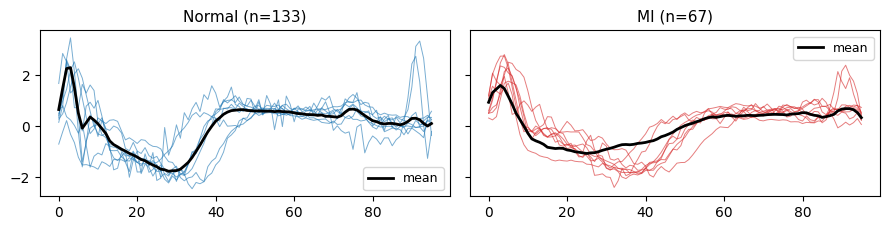

In [2]:
X_tr, y_tr, X_te, y_te = UCR_UEA_datasets().load_dataset('ECG200')
X = np.vstack([X_tr.squeeze(-1), X_te.squeeze(-1)])
y_raw = np.concatenate([y_tr, y_te])
y_true = (y_raw == -1).astype(int)
sub = np.where(y_true == 1, "MI", "Normal")
N, L = X.shape
print(f"N={N}, Normal={(y_true==0).sum()}, MI={(y_true==1).sum()}")

fig, axes = plt.subplots(1, 2, figsize=(9, 2.4), sharey=True)
for ax, cls, color in zip(axes, ("Normal", "MI"), ("C0", "C3")):
    for i in np.where(sub == cls)[0][:8]:
        ax.plot(X[i], color=color, lw=0.7, alpha=0.6)
    ax.plot(X[sub == cls].mean(0), color="k", lw=2.0, label="mean")
    ax.set_title(f"{cls} (n={(sub==cls).sum()})", fontsize=11)
    ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## Filtrations

Two axes on the full set of 200 beats:

`filt_shape` -- L2 between z-normalized waveforms.

`filt_amp` -- |peak2peak_i - peak2peak_j|.

In [3]:
Xz = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-9)
amp = X.max(1) - X.min(1)

D_shape = cdist(Xz, Xz)
D_amp = np.abs(amp[:, None] - amp[None, :])

iu, ju = np.triu_indices(N, k=1)
edges = list(zip(iu.tolist(), ju.tolist()))
filt_shape = assemble_filtration(N, edges, D_shape[iu, ju])
filt_amp   = assemble_filtration(N, edges, D_amp[iu, ju])
print(f"N={N}, edges={len(edges)}")

N=200, edges=19900


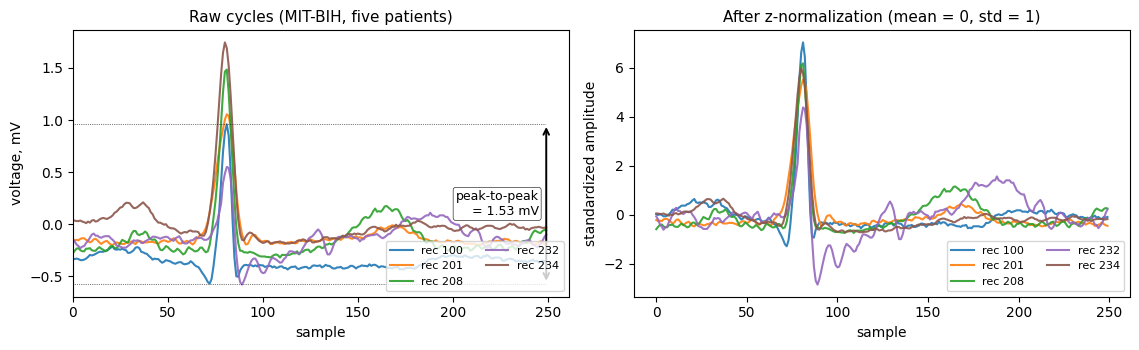

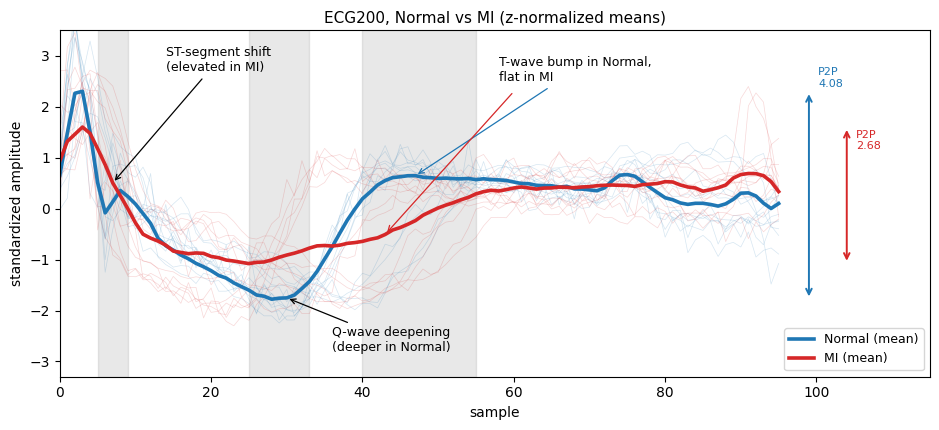

P2P Normal mean cycle:4.082
P2P MI mean cycle: 2.680


In [4]:
from pathlib import Path
import wfdb
FIG = Path("figures")
FIG.mkdir(exist_ok=True)

records = ['100', '201', '208', '232', '234']
cycles_raw = []
for rec_name in records:
    rec = wfdb.rdrecord(f'data/mitdb/{rec_name}', sampto=20000)
    ann = wfdb.rdann(f'data/mitdb/{rec_name}', 'atr', sampto=20000)
    sig = rec.p_signal[:, 0]
    for r in ann.sample[3:]:
        if r >= 80 and r + 170 < len(sig):
            cycles_raw.append(sig[r - 80 : r + 170])
            break

cycles_z = [(c - c.mean()) / (c.std() + 1e-9) for c in cycles_raw]
colors = ['C0', 'C1', 'C2', 'C4', 'C5']

fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))

ax = axes[0]
for c, rec, col in zip(cycles_raw, records, colors):
    ax.plot(c, color=col, lw=1.5, label=f'rec {rec}', alpha=0.9)

c0 = cycles_raw[0]
mx, mn = c0.max(), c0.min()
xpos = len(c0) - 1
ax.annotate('', xy=(xpos, mx), xytext=(xpos, mn),
            arrowprops=dict(arrowstyle='<->', color='black', lw=1.4))
ax.hlines([mx, mn], 0, xpos, colors='black', lw=0.5, linestyles=':')
ax.text(xpos - 4, (mx + mn) / 2,
        f"peak-to-peak\n= {mx - mn:.2f} mV",
        ha='right', va='center', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='black', lw=0.4))
ax.set_xlim(0, xpos + 12)
ax.set_title("Raw cycles (MIT-BIH, five patients)", fontsize=11)
ax.set_xlabel("sample"); ax.set_ylabel("voltage, mV")
ax.legend(fontsize=8, loc='lower right', ncol=2)

ax = axes[1]
for c, rec, col in zip(cycles_z, records, colors):
    ax.plot(c, color=col, lw=1.5, label=f'rec {rec}', alpha=0.9)
ax.set_title("After z-normalization (mean = 0, std = 1)", fontsize=11)
ax.set_xlabel("sample"); ax.set_ylabel("standardized amplitude")
ax.legend(fontsize=8, loc='lower right', ncol=2)

fig.tight_layout()
fig.savefig(FIG / "ecg_normalization_demo.png", dpi=150, bbox_inches="tight")
plt.show()

mu_n_z = Xz[sub == "Normal"].mean(0)
mu_m_z = Xz[sub == "MI"].mean(0)
p2p_n = mu_n_z.max() - mu_n_z.min()
p2p_m = mu_m_z.max() - mu_m_z.min()

fig, ax = plt.subplots(1, 1, figsize=(9.5, 4.4))

rng = np.random.RandomState(0)
sample_n = rng.choice(np.where(sub == "Normal")[0], 12, replace=False)
sample_m = rng.choice(np.where(sub == "MI")[0], 12, replace=False)
for i in sample_n:
    ax.plot(Xz[i], color="C0", lw=0.5, alpha=0.18)
for i in sample_m:
    ax.plot(Xz[i], color="C3", lw=0.5, alpha=0.18)
ax.plot(mu_n_z, color="C0", lw=2.6, label="Normal (mean)")
ax.plot(mu_m_z, color="C3", lw=2.6, label="MI (mean)")

ax.axvspan(5, 9, color='gray', alpha=0.18)
ax.annotate("ST-segment shift\n(elevated in MI)",
            xy=(7, mu_m_z[7]), xytext=(14, 2.7),
            fontsize=9, ha='left',
            arrowprops=dict(arrowstyle='->', color='black', lw=0.9))

ax.axvspan(25, 33, color='gray', alpha=0.18)
ax.annotate("Q-wave deepening\n(deeper in Normal)",
            xy=(30, mu_n_z[30]), xytext=(36, -2.8),
            fontsize=9, ha='left',
            arrowprops=dict(arrowstyle='->', color='black', lw=0.9))

ax.axvspan(40, 55, color='gray', alpha=0.18)
ax.annotate("T-wave bump in Normal,\nflat in MI",
            xy=(47, mu_n_z[47]), xytext=(58, 2.5),
            fontsize=9, ha='left',
            arrowprops=dict(arrowstyle='->', color='C0', lw=0.9))
ax.annotate("",
            xy=(43, mu_m_z[43]), xytext=(60, 2.3),
            arrowprops=dict(arrowstyle='->', color='C3', lw=0.9))

x_p2p_n = 99
x_p2p_m = 104
ax.annotate('', xy=(x_p2p_n, mu_n_z.max()), xytext=(x_p2p_n, mu_n_z.min()),
            arrowprops=dict(arrowstyle='<->', color='C0', lw=1.4))
ax.annotate('', xy=(x_p2p_m, mu_m_z.max()), xytext=(x_p2p_m, mu_m_z.min()),
            arrowprops=dict(arrowstyle='<->', color='C3', lw=1.4))
ax.text(x_p2p_n + 1.2, mu_n_z.max() + 0.05,
        f"P2P\n{p2p_n:.2f}",
        ha='left', va='bottom', fontsize=8, color='C0')
ax.text(x_p2p_m + 1.2, mu_m_z.max() - 0.05,
        f"P2P\n{p2p_m:.2f}",
        ha='left', va='top', fontsize=8, color='C3')

ax.set_ylim(-3.3, 3.5)
ax.set_xlim(0, 115)
ax.set_title("ECG200, Normal vs MI (z-normalized means)", fontsize=11)
ax.set_xlabel("sample")
ax.set_ylabel("standardized amplitude")
ax.legend(fontsize=9, loc='lower right')

fig.tight_layout()
fig.savefig(FIG / "ecg200_features.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"P2P Normal mean cycle:{p2p_n:.3f}")
print(f"P2P MI mean cycle: {p2p_m:.3f}")

## Clustering

Each method runs once on the full set. Metrics: ARI, NMI, and binary
precision/recall/F1 after Hungarian alignment to ground-truth labels.

Bifiltration on `filt_shape x filt_amp`, simplify mode, `slope = 1`,
`K = 2`, `min_size = N / 10`.

KMeans, Ward, GMM, HDBSCAN run on the z-normalized waveform `Xz`
(L = 96) so that they see the same shape information as `filt_shape`.

For F1/P/R cluster IDs are remapped to ground-truth class IDs via
Hungarian assignment (overlap-maximizing).

In [6]:
from sklearn.metrics import f1_score, precision_score, recall_score

K = 2
min_size = N // 10  # for N=200 gives 20

bif_res = run_bifiltration_edges(N, filt_shape, filt_amp,
                                 method="simplify", n_clusters=K,
                                 slope=1.0, min_size=min_size)
labels_bif = bif_res.labels_combined

labels_km = KMeans(n_clusters=K, n_init=50, max_iter=500,
                     random_state=42).fit_predict(Xz)
labels_ward = AgglomerativeClustering(n_clusters=K, linkage="ward").fit_predict(Xz)
labels_hdb = hdbscan.HDBSCAN(min_cluster_size=min_size).fit_predict(Xz)

methods = {
    f"Bifiltration (slope=1, m={min_size})": labels_bif,
    "KMeans on Xz": labels_km,
    "Ward on Xz": labels_ward,
    f"HDBSCAN on Xz (mcs={min_size})": labels_hdb,
}

rows = []
for name, labels in methods.items():
    labels = np.asarray(labels)
    a, _ = align_hungarian(labels, y_true)
    pred = (a == 2).astype(int)
    rows.append({
        "method": name,
        "ARI": adjusted_rand_score(y_true, labels),
        "NMI": normalized_mutual_info_score(y_true, labels),
        "P": precision_score(y_true, pred, zero_division=0),
        "R": recall_score(y_true, pred, zero_division=0),
        "F1": f1_score(y_true, pred, zero_division=0),
    })
df = pd.DataFrame(rows).sort_values("F1", ascending=False).reset_index(drop=True).round(3)
df

,method,ARI,NMI,P,R,F1
0,"Bifiltration (slope=1, m=20)",0.394,0.381,0.653,0.955,0.776
1,HDBSCAN on Xz (mcs=20),0.389,0.351,0.642,0.776,0.703
2,Ward on Xz,0.244,0.149,0.650,0.582,0.614
3,KMeans on Xz,0.219,0.129,0.648,0.522,0.579


## Predictions in the (shape, amp) plane

Each point is one heartbeat in 2D feature space:

x = `||z(x) - mean_z||_2`, shape distance to the mean z-normalized beat

y = `peak2peak(x)`, amplitude

Color is predicted cluster after Hungarian alignment to ground-truth labels where red is MI, gray is Normal.

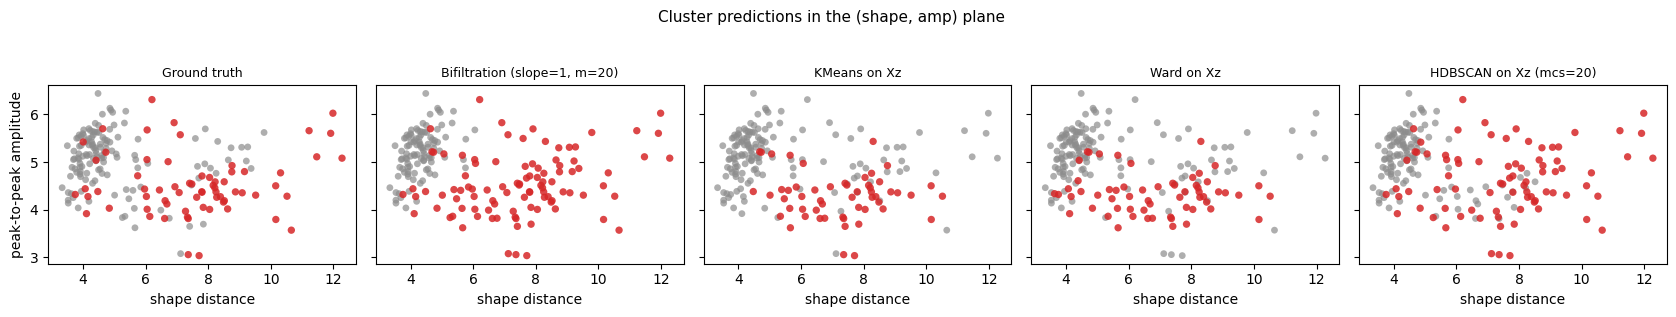

In [7]:
PRED_COLORS = {0: "0.55", 1: "C3"}

shape_dist_vis = np.linalg.norm(Xz - Xz.mean(0), axis=1)

methods_to_show = [("Ground truth", y_true)] + [(name, labels) for name, labels in methods.items()]

fig, axes = plt.subplots(1, len(methods_to_show), figsize=(17, 3.0),
                         sharex=True, sharey=True)
for ax, (name, labels) in zip(axes, methods_to_show):
    labels = np.asarray(labels)
    if name == "Ground truth":
        aligned = labels
    else:
        a, _ = align_hungarian(labels, y_true)
        aligned = (a == 2).astype(int)
    ax.scatter(shape_dist_vis[aligned == 0], amp[aligned == 0], s=24, c=PRED_COLORS[0],
               alpha=0.7, edgecolors="none")
    ax.scatter(shape_dist_vis[aligned == 1], amp[aligned == 1], s=28, c=PRED_COLORS[1],
               alpha=0.85, edgecolors="none")
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("shape distance")
axes[0].set_ylabel("peak-to-peak amplitude")
fig.suptitle("Cluster predictions in the (shape, amp) plane", y=1.04, fontsize=11)
fig.tight_layout()
plt.show()

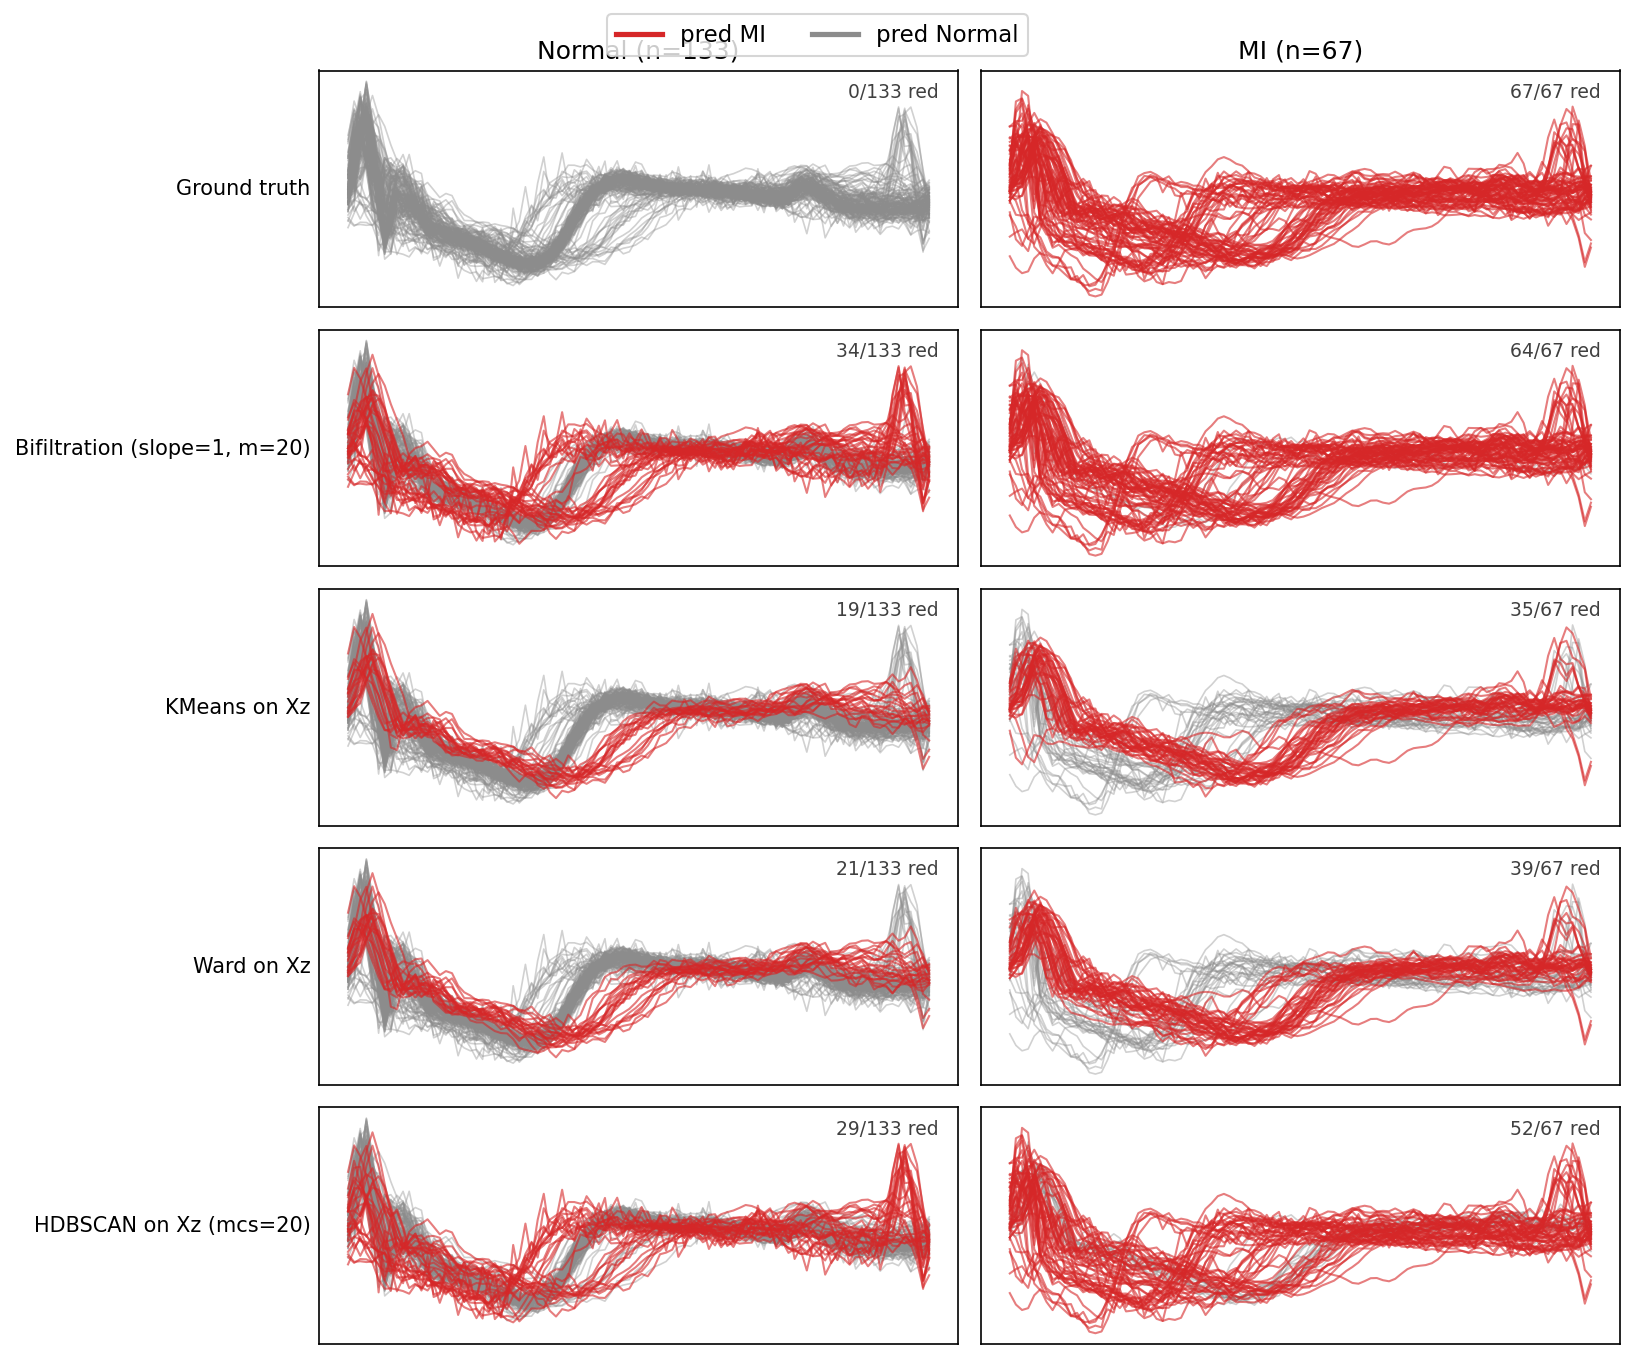

In [8]:
CLS_ORDER = ("Normal", "MI")
PRED_COLORS = {0: "0.55", 1: "C3"}

rows_to_show = [("Ground truth", y_true)] + [(name, labels) for name, labels in methods.items()]

fig, axes = plt.subplots(len(rows_to_show), 2, figsize=(11, 1.8 * len(rows_to_show)),
                         sharex=True, sharey=True, dpi=150)
for row, (name, labels) in enumerate(rows_to_show):
    labels = np.asarray(labels)
    if name == "Ground truth":
        aligned = labels
    else:
        a, _ = align_hungarian(labels, y_true)
        aligned = (a == 2).astype(int)
    for col, c in enumerate(CLS_ORDER):
        ax = axes[row, col]
        idxs = np.where(sub == c)[0]
        for i in idxs[aligned[idxs] == 0]:
            ax.plot(X[i], color=PRED_COLORS[0], lw=0.8, alpha=0.4)
        for i in idxs[aligned[idxs] == 1]:
            ax.plot(X[i], color=PRED_COLORS[1], lw=1.0, alpha=0.6)
        n_pos = int(aligned[idxs].sum())
        ax.set_xticks([])
        ax.set_yticks([])
        ax.text(0.97, 0.95, f"{n_pos}/{len(idxs)} red", transform=ax.transAxes,
                ha="right", va="top", fontsize=9, color="0.25")
        if row == 0: ax.set_title(f"{c} (n={len(idxs)})", fontsize=12)
        if col == 0: ax.set_ylabel(name, fontsize=10, rotation=0, ha="right", va="center")

handles = [plt.Line2D([0], [0], color=PRED_COLORS[1], lw=2.5, label="pred MI"),
           plt.Line2D([0], [0], color=PRED_COLORS[0], lw=2.5, label="pred Normal")]
fig.legend(handles=handles, loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.01), fontsize=11)
fig.tight_layout()
plt.show()